# Feature extraction: Final MSA Size

Final MSA Size from "Final (deduplicated) MSA size:____" in AF logs.

In the log file there are two final deduplicated MSA counts (one per chain), their counts are added up to return the Final MSA Size (one value per complex).

In [1]:
import re
import os

In [2]:
def extract_final_MSA(log_file_path):
    msa_sizes = !grep -oP 'Final \(deduplicated\) MSA size:\s*\K[0-9]+' {log_file_path}
    msa_sizes_numeric = [int(x) for x in msa_sizes]
    final_msa = sum(msa_sizes_numeric)
    
    return final_msa


## A) RNase

Final MSA extraction

In [3]:
pos_log_path = "/mnt/storage/ana01/results/afm_10_RNase_22_copy/logs"
neg_log_path = "/mnt/storage/ana01/results/afm_11_RNase_13_no_MOV10_copy/logs"


def batch_final_msa_extraction(log_folder_path):
    results = {}
    for root, dirs, files in os.walk(log_folder_path):
        for file in files: 
            if file.endswith(".log"):
                file_path = os.path.join(log_folder_path, file)
                final_msa = extract_final_MSA(file_path)
                complex_name = file.split("_multimer")[0]
                results[complex_name] = final_msa
   
    return results

results_pos = batch_final_msa_extraction(pos_log_path)
results_neg = batch_final_msa_extraction(neg_log_path)


In [4]:
#From dictionary to dataframe, joining groups, adding labels
import pandas as pd


df_pos = pd.DataFrame(list(results_pos.items()), columns=['complex_name', 'final_msa'])
df_pos['group'] = 'RNase-independent' 


df_neg = pd.DataFrame(list(results_neg.items()), columns=['complex_name', 'final_msa'])
df_neg['group'] = 'RNase-dependent'

df = pd.concat([df_pos, df_neg], ignore_index=True)

Insight into the top-scoring protein identities

In [5]:
df.sort_values(by='final_msa', ascending=False, inplace=True)
df.head()

,complex_name,final_msa,group
0,PARP1_ORF2,35734,RNase-independent
26,UPF1_ORF2,35027,RNase-dependent
12,PABPC1_ORF2,33089,RNase-independent
7,PABPC4_ORF2,32913,RNase-independent
18,FKBP4_ORF2,32780,RNase-independent


Mann-Whitney U test (non-parametric, one-sided)

In [9]:
from scipy.stats import mannwhitneyu

# Separating the groups
pos_values = df.loc[df['group'] == 'RNase-independent', 'final_msa']
neg_values = df.loc[df['group'] == 'RNase-dependent', 'final_msa']

# MWU Test
stat, p_value = mannwhitneyu(pos_values, neg_values, alternative='two-sided')

print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Mann-Whitney U statistic: 173.0
P-value: 3.1388e-01


There is no significant difference between distributions of Final MSA size across RNase-independent and RNase-dependent protein groups. 

Histogram (Figure 11)

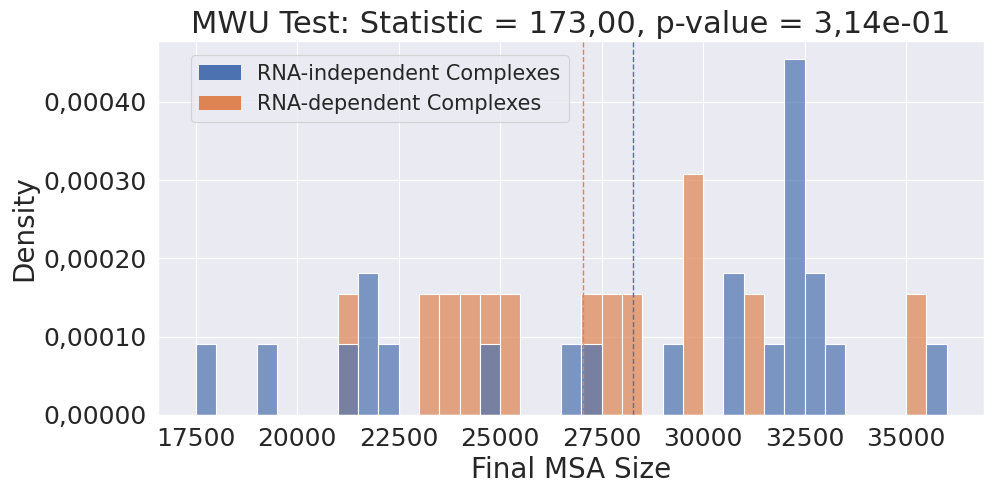

In [20]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np

sns.set_style("darkgrid")
sns.set_context("paper", font_scale=0.9)

palette = {
    'RNase-independent': sns.color_palette('deep')[0],
    'RNase-dependent': sns.color_palette('deep')[1]
}

plt.figure(figsize=(10, 5))

bin_width = 500
min_edge = (df["final_msa"].min() // bin_width) * bin_width
max_edge = ((df["final_msa"].max() // bin_width) + 1) * bin_width
bins = np.arange(min_edge, max_edge + bin_width, bin_width)

sns.histplot(
    data=df,
    x='final_msa',
    hue='group',
    bins=bins,
    stat='density',
    common_norm=False,
    alpha=0.7,
    palette=palette
)

mean_independent = df[df['group'] == 'RNase-independent']['final_msa'].mean()
mean_dependent = df[df['group'] == 'RNase-dependent']['final_msa'].mean()

plt.axvline(
    mean_independent,
    color=palette['RNase-independent'],
    linestyle='--',
    linewidth=1
)

plt.axvline(
    mean_dependent,
    color=palette['RNase-dependent'],
    linestyle='--',
    linewidth=1
)

ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:.5f}".replace(".", ",")))

title = f"MWU Test: Statistic = {stat:.2f}, p-value = {p_value:.2e}"
title = title.replace(".", ",")

plt.title(title, fontsize=22)
plt.xlabel("Final MSA Size", fontsize=20)
plt.ylabel("Density", fontsize=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

legend_handles = [
    Patch(facecolor=palette['RNase-independent'], edgecolor='none', label='RNA-independent Complexes'),
    Patch(facecolor=palette['RNase-dependent'], edgecolor='none', label='RNA-dependent Complexes')
]

plt.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.51, 0.99),
    frameon=True,
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "/mnt/storage/ana01/results/thesis_figures/RNA_total_MSA_histogram.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## B) L1KD EXPERIMENTAL DATASET

Final MSA extraction

In [23]:
pos_log_path = "/mnt/storage/ana01/results/all_models_FCpos_no_CLK2_original/logs"
neg_log_path = "/mnt/storage/ana01/results/afm_6_L1KD_FCneg_no__MACF1_ABCG2_original/logs"


def batch_final_msa_extraction(log_folder_path):
    results = {}
    for root, dirs, files in os.walk(log_folder_path):
        for file in files: 
            if file.endswith(".log"):
                file_path = os.path.join(log_folder_path, file)
                final_msa = extract_final_MSA(file_path)
                complex_name = file.split("_multimer")[0]
                results[complex_name] = final_msa
   
    return results

results_pos = batch_final_msa_extraction(pos_log_path)
results_neg = batch_final_msa_extraction(neg_log_path)


In [24]:
#From dictionary to dataframe, joining groups, adding labels
import pandas as pd


df_pos = pd.DataFrame(list(results_pos.items()), columns=['complex_name', 'final_msa'])
df_pos['group'] = 'L1KD correlated' 


df_neg = pd.DataFrame(list(results_neg.items()), columns=['complex_name', 'final_msa'])
df_neg['group'] = 'L1KD anti-correlated'

df = pd.concat([df_pos, df_neg], ignore_index=True)

MWU test

In [25]:
from scipy.stats import mannwhitneyu

# Separating the groups
pos_values = df.loc[df['group'] == 'L1KD correlated', 'final_msa']
neg_values = df.loc[df['group'] == 'L1KD anti-correlated', 'final_msa']

# MWU Test
stat, p_value = mannwhitneyu(pos_values, neg_values, alternative='two-sided')

print(f"Mann-Whitney U statistic: {stat}")
print(f"P-value: {p_value:.4e}")

Mann-Whitney U statistic: 1699.0
P-value: 3.7065e-03


Histogram (Figure 16)

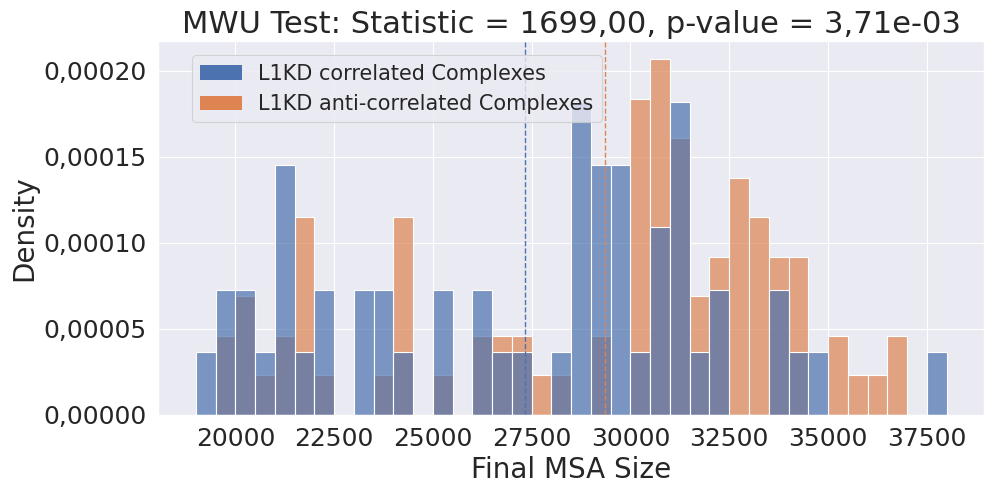

In [26]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np

sns.set_style("darkgrid")
sns.set_context("paper", font_scale=0.9)

palette = {
    'L1KD correlated': sns.color_palette('deep')[0],
    'L1KD anti-correlated': sns.color_palette('deep')[1]
}

plt.figure(figsize=(10, 5))

bin_width = 500
min_edge = (df["final_msa"].min() // bin_width) * bin_width
max_edge = ((df["final_msa"].max() // bin_width) + 1) * bin_width
bins = np.arange(min_edge, max_edge + bin_width, bin_width)

sns.histplot(
    data=df,
    x='final_msa',
    hue='group',
    bins=bins,
    stat='density',
    common_norm=False,
    alpha=0.7,
    palette=palette
)

mean_correlated = df[df['group'] == 'L1KD correlated']['final_msa'].mean()
mean_anticorrelated = df[df['group'] == 'L1KD anti-correlated']['final_msa'].mean()

plt.axvline(
    mean_correlated,
    color=palette['L1KD correlated'],
    linestyle='--',
    linewidth=1
)

plt.axvline(
    mean_anticorrelated,
    color=palette['L1KD anti-correlated'],
    linestyle='--',
    linewidth=1
)

ax = plt.gca()
ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=5))
ax.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x:.5f}".replace(".", ","))
)

title = f"MWU Test: Statistic = {stat:.2f}, p-value = {p_value:.2e}"
title = title.replace(".", ",")

plt.title(title, fontsize=22)
plt.xlabel("Final MSA Size", fontsize=20)
plt.ylabel("Density", fontsize=20)

plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

legend_handles = [
    Patch(
        facecolor=palette['L1KD correlated'],
        edgecolor='none',
        label='L1KD correlated Complexes'
    ),
    Patch(
        facecolor=palette['L1KD anti-correlated'],
        edgecolor='none',
        label='L1KD anti-correlated Complexes'
    )
]

plt.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(0.55, 0.99),
    frameon=True,
    fontsize=15
)

plt.tight_layout()

plt.savefig(
    "/mnt/storage/ana01/results/thesis_figures/L1KD_total_MSA_histogram.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()